# Analiza i preporuka kniga
## Čišćenje skupa

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_json('output.json')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23646 entries, 0 to 23645
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   isbn       23646 non-null  object
 1   naslov     23646 non-null  object
 2   autor      23646 non-null  object
 3   zanr       23646 non-null  object
 4   izdavac    23646 non-null  object
 5   godina     23646 non-null  int64 
 6   br_strana  23646 non-null  int64 
 7   povez      23646 non-null  object
 8   dimenzije  23646 non-null  object
 9   pismo      23646 non-null  object
 10  opis       23646 non-null  object
 11  cena       23646 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 2.2+ MB


In [4]:
df.duplicated().sum()

0

Nema nultih vrednosti, nema duplikata. Ova baza podataka sadrži mnogobrojne kategorične podatke. Cilj ove skripte je da analizira podatke i iskoristi ih za implementiranje različitih modela mašinskog učenja. Trenutno u projektu nije cilj implementacija neuralnih mreža i jezičkih modela. U budićnosti jeste, tako da do tad zbog preglednosti i memorije opis biće obrisan.

In [6]:
df = df.drop(columns='opis')
df.columns

Index(['isbn', 'naslov', 'autor', 'zanr', 'izdavac', 'godina', 'br_strana',
       'povez', 'dimenzije', 'pismo', 'cena'],
      dtype='object')

In [7]:
df.describe()

,godina,br_strana,cena
count,23646.000000,23646.00000,23646.000000
mean,2019.480631,223.09380,1184.734247
std,324.412252,187.99647,1036.293535
min,15.000000,-1.00000,50.000000
25%,2015.000000,100.00000,699.000000
50%,2019.000000,197.00000,990.000000
75%,2022.000000,304.00000,1320.000000
max,21016.000000,6687.00000,28985.000000


Na osnovu inicijalnih podataka o numeričkim vrednostima može se videti da podaci moraju da se čiste jer min i max godine nisu realne. Takođe treba dalje ispitati raspodele cena i broja strana i videti koliko raspodela odstupa od normalne raspodele (koja je u ovom slučaju očekivana).

<Axes: xlabel='godina'>

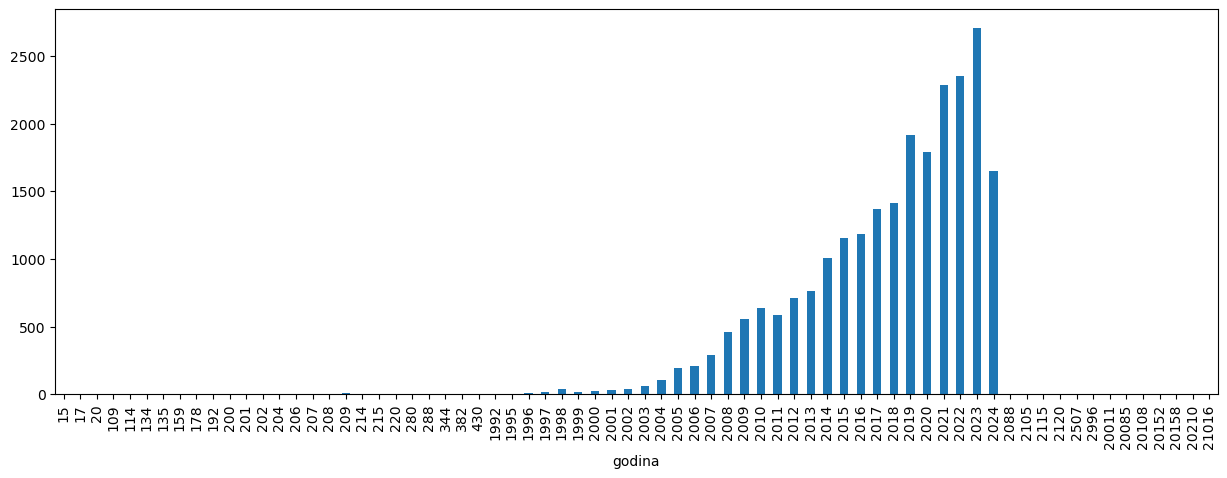

In [9]:
df['godina'].value_counts().sort_index().plot(kind='bar', figsize=(15,5))

In [10]:
print('U slučaju otklanjanja svih nelogičnih podataka, bilo bi otklonjeno', df[(df['godina'] < 1992) | (df['godina'] > 2024)].shape[0]/df.shape[0]*100, '% podataka') 

U slučaju otklanjanja svih nelogičnih podataka, bilo bi otklonjeno 0.2579717499788548 % podataka


<Axes: xlabel='cena'>

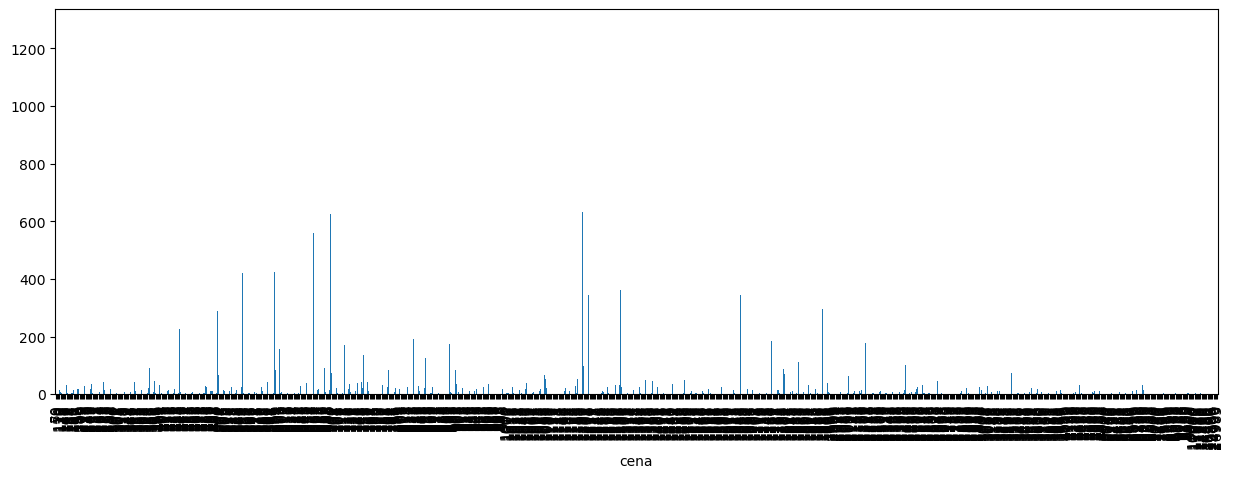

In [11]:
df['cena'].value_counts().sort_index().plot(kind='bar', figsize=(15,5))

<Axes: xlabel='br_strana'>

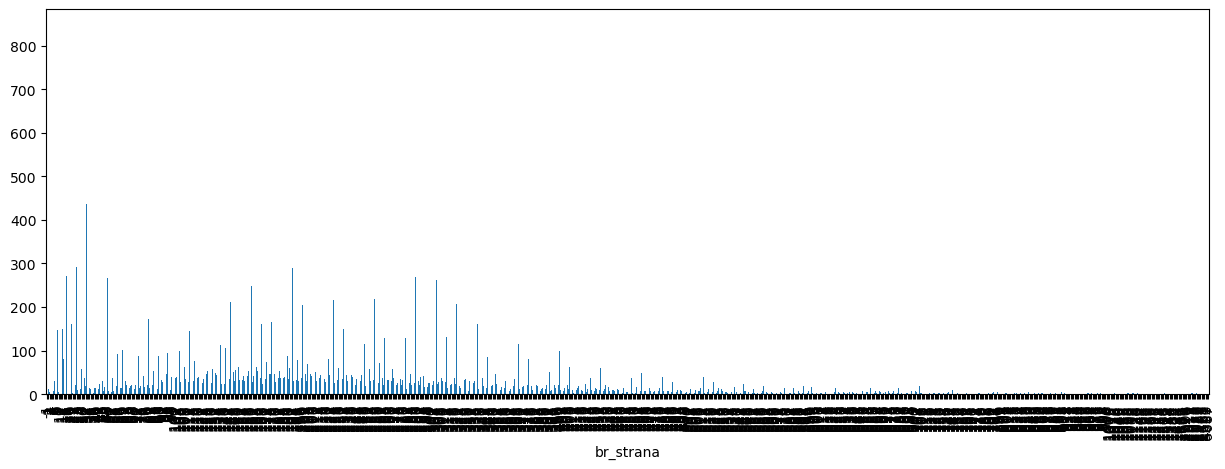

In [12]:
df['br_strana'].value_counts().sort_index().plot(kind='bar', figsize=(15,5))

In [13]:
print('U slučaju otklanjanja svih nelogičnih podataka, bilo bi otklonjeno', df[df['br_strana'] < 1].shape[0]/df.shape[0]*100, '% podataka')

U slučaju otklanjanja svih nelogičnih podataka, bilo bi otklonjeno 3.5608559587245203 % podataka


Posle procesuiranja samo 3 od 11 atributa već bi potencijalni gubitak podataka bio blizu 4%. Za sada ću označiti potencijalne podatke za brisanje pa obradom kategoričkih promenljivih ću odlučiti kako bih pristupio čišćenju ovih podataka.

In [15]:
#uslovi
u1 = (df['godina'] < 1992) | (df['godina'] > 2024) #filter godina
u2 = df['br_strana'] < 1 #filter stranica

In [16]:
kategoricki = df.dtypes[df.dtypes == 'object'].index
df[kategoricki].describe()

,isbn,naslov,autor,zanr,izdavac,povez,dimenzije,pismo
count,23646,23646,23646,23646,23646,23646,23646,23646
unique,23646,22997,12145,181,606,3,1302,4
top,9788680120713,ZONA ZAMFIROVA,grupa autora,DOMAĆI ROMAN,VULKAN IZDAVAŠTVO,Broš,13x20,Latinica
freq,1,8,1316,2156,2883,16511,4709,13984


In [17]:
print(df['pismo'].value_counts(), df['povez'].value_counts())

pismo
Latinica    13984
Ćirilica     9002
              659
Ćir/Lat         1
Name: count, dtype: int64 povez
Broš    16511
Tvrd     6022
         1113
Name: count, dtype: int64


In [18]:
df['dimenzije'].unique()

array(['16,5x23,5', '14x20', '14,5x20,5x18', ..., '5x6', '30,5X21,5',
       '18,5x11,5'], dtype=object)

Čišćenje unosa:

Funkcija prvo proverava da li je vrednost prazna ili sadrži samo jedan broj, i u tim slučajevima vraća NaN.
Svaka velika slova "X" u dimenzijama se konvertuju u mala slova.
Simboli poput ?, razmaka (\u00a0), ili bilo koji razmaci između brojeva se zamenjuju sa "x" kako bi se standardizovao format.
Decimalne vrednosti odvojene zarezom (npr. 20,5) se zamenjuju tačkom (.) kako bi se obezbedila doslednost u formatu decimala.

Rukovanje dodatnim vrednostima: Ako se pronađe više od dva broja u formatu (npr. 17x24x3), pretpostavlja se da treći broj predstavlja debljinu, koja nije relevantna, i zadržavaju se samo glavne dve dimenzije (17x24).
Funkcija proverava da li neka od dimenzija prelazi 50. Ako je to slučaj, pretpostavlja se da je vrednost napisana u mm, a ne u cm. Deli date vrednosti sa 10. Ako i dalje prelaze 50, vraća NaN, jer prema vašim američkim specifikacijama za knjige, nijedna dimenzija ne bi trebalo da bude veća od 50.

Vraćanje doslednog formata: Ako se pronađu dve dimenzije, one se sortiraju u format manji_broj x veći_broj. Ako su brojevi isti (npr. 20x20), ostaju u formatu 20x20.

Rukovanje specifičnim formatima: Za slučajeve kada su dimenzije u formatima kao što su A4, A5, potrebno je da se konvertuju u numeričke formate (npr. A4 = 21 x 29.7).
Ako je format jednostavna pojedinačna dimenzija (npr. A4), smatra se nevalidnim, pa se postavlja na NaN.

Primena funkcije: Funkcija clean_format() se primenjuje na kolonu 'dimenzije' u DataFrame-u knjiga kako bi se očistili i ponovo formatirali svi unosi.

In [20]:
df['dimenzije'] = df['dimenzije'].str.replace(r"\u00d7", "x", regex=True)
df['dimenzije'] = df['dimenzije'].str.replace(r"cm", "", regex=True)
df['dimenzije'] = df['dimenzije'].str.replace(r"\u00a0", "", regex=True)
df['dimenzije'] = df['dimenzije'].str.replace(r"\?", "x", regex=True)
df['dimenzije'] = df['dimenzije'].str.replace(r",", ".", regex=True)
df['dimenzije'] = df['dimenzije'].str.replace(r"X", "x", regex=True)
df['dimenzije'] = df['dimenzije'].str.replace(r"\s", "", regex=True)

df['dimenzije'].value_counts()

def dve_dimenzije(vrednost):
    # Proveravamo da li je vrednost string i da li sadrži 'x'
    if isinstance(vrednost, str) and "x" in vrednost:
        dimenzije = vrednost.split("x")
        # Pokušavamo da konvertujemo svaku vrednost u float
        try:
            dimenzije = [float(dim) for dim in dimenzije if dim]
        except ValueError:
            return ""  # Vraćamo prazan string ako konverzija ne uspe
        
        # Sortiramo dimenzije i uklanjamo najmanju ako ih ima tri
        dimenzije.sort(reverse=True)
        if len(dimenzije) > 3:
            return ""  # Više od 3 vrednosti je nevalidno
        elif len(dimenzije) == 3:
            dimenzije.pop()  # Uklanjamo najmanju dimenziju
        elif len(dimenzije) < 2:
            return ""  # Nedovoljno dimenzija

        # Normalizujemo dimenzije ako su prevelike
        if dimenzije[1] > 50 or dimenzije[0] > 50:
            dimenzije[1] /= 50
            dimenzije[0] /= 50
            if dimenzije[1] > 50 or dimenzije[0] > 50:
                return ""
                
        # Vraćamo sređene dimenzije u formatu 'DužinaxŠirina'
        return f"{dimenzije[1]}x{dimenzije[0]}"
    
    return ""  # Vraćamo prazan string ako nema 'x' u vrednosti

df['dimenzije'] = df['dimenzije'].apply(dve_dimenzije)
df['dimenzije'].value_counts()

dimenzije
13.0x20.0    4910
14.5x20.5    4239
             1722
17.0x24.0    1227
14.8x21.0     981
             ... 
14.5x27.0       1
14.5x25.0       1
14.5x24.0       1
14.5x26.0       1
22.0x29.4       1
Name: count, Length: 830, dtype: int64

Radi dodatnih predikcija biće dodata još jedna vrednost a to je površina koja se dobija množenjem dimenzija formata. Veća površina papira je veći trošak za proizvođača što može uticati na cenu knjige pa će vrednost biti pridodata

In [22]:
u3 = (df['isbn'] == '') | (df['isbn'] == ' ') | (df['naslov'] == '') | (df['naslov'] == ' ') | \
     (df['autor'] == '') | (df['autor'] == ' ') | (df['zanr'] == '') | (df['zanr'] == ' ') | \
     (df['izdavac'] == '') | (df['izdavac'] == ' ') | (df['povez'] == '') | (df['povez'] == ' ') | \
     (df['dimenzije'] == '') | (df['dimenzije'] == ' ') | (df['pismo'] == '') | (df['pismo'] == ' ')

print(df[u3|u2|u1].shape[0]/df.shape[0]*100, '% podataka se gubi ako se uklone sve nepoznate i pogrešne vrednosti')

15.490992133976148 % podataka se gubi ako se uklone sve nepoznate i pogrešne vrednosti


Sa obzirom na urađene upite odlučujem sledeće:
 - Godine - nemoguće je rekonstruisati pogrešne godine jer nije konzistentna greška na kojoj cifri se greška dešava. Tako da ću čuvati godine samo između 1992 i 2024
 - Broj strana - biće uklonjene vrednosti manje od 0
 - Cena - za sad će ostati takva kakva je
 - Sve vrednosti kojima nedostaju 2 ili više podataka biće obrisani
 - U slučaju pisma i poveza, biće kao i za sve ostale nedostupne vrednosti dodata vrednost 'drugo' dok će jedna jedina vrednost 'ćir/lat' biti pridodata kategoriji 'drugo'.

In [24]:
df = df[~(u1 | u2)]
df.shape

(22748, 11)

In [25]:
# Promena vrednosti u kolonama 'povez' i 'pismo'
df['povez'] = df['povez'].replace(['', ' '], 'drugo')
df['pismo'] = df['pismo'].replace(['', ' ', 'Ćir/Lat'], 'drugo')

# Prikaz broja pojavljivanja vrednosti u kolonama 'pismo' i 'povez'
print(df['pismo'].value_counts())
print(df['povez'].value_counts())


pismo
Latinica    13487
Ćirilica     8654
drugo         607
Name: count, dtype: int64
povez
Broš     15937
Tvrd      5841
drugo      970
Name: count, dtype: int64


In [26]:
df.replace(['', ' '], np.nan, inplace=True)
df = df[df.isnull().sum(axis=1) < 2]

df.shape

(22649, 11)

In [27]:
def calculate_surface(dimensions):
    if pd.isna(dimensions) or not isinstance(dimensions, str):
        return np.nan
    try:
        num1, num2 = map(float, dimensions.replace(" ", "").split("x"))
        return num1 * num2
    except (ValueError, AttributeError):
        return np.nan

# Dodavanje nove kolone sa površinom stranice
df["povrsina"] = df["dimenzije"].apply(calculate_surface)

# Prikaz broja ponavljanja svake vrednosti površine
print(df['povrsina'].value_counts())

povrsina
260.00    4747
297.25    4001
408.00    1191
310.80     963
280.00     709
          ... 
405.90       1
612.50       1
262.70       1
668.25       1
262.40       1
Name: count, Length: 783, dtype: int64


In [28]:
df.isna().sum()

isbn            1
naslov          0
autor         106
zanr            0
izdavac       172
godina          0
br_strana       0
povez           0
dimenzije    1434
pismo           0
cena            0
povrsina     1434
dtype: int64

In [29]:
df['povrsina'].describe()

count    21215.000000
mean       342.272751
std        132.754249
min          1.073000
25%        260.000000
50%        297.250000
75%        391.350000
max       1765.000000
Name: povrsina, dtype: float64

In [30]:
df[df['isbn'].isna()]

,isbn,naslov,autor,zanr,izdavac,godina,br_strana,povez,dimenzije,pismo,cena,povrsina
5996,NaN,SRPSKE SVETINJE ŠAR PLANINE PRIZRENA I OKOLINE,Aleksandra Novakov,ISTORIJA UMETNOSTI,MATICA SRPSKA,2019,47,Broš,17.6x25.0,Ćirilica,350,440.0


In [31]:
df[df['autor'] == 'Aleksandra Novakov']

,isbn,naslov,autor,zanr,izdavac,godina,br_strana,povez,dimenzije,pismo,cena,povrsina
5996,NaN,SRPSKE SVETINJE ŠAR PLANINE PRIZRENA I OKOLINE,Aleksandra Novakov,ISTORIJA UMETNOSTI,MATICA SRPSKA,2019,47,Broš,17.6x25.0,Ćirilica,350,440.0


ISBN ne govori puno o knjizi tako da ce ova vrednost biti sklonjena radi lakse obrade, dok ce dimenzije biti sklonjene jer nece biti korisceni neki napredniji modeli a informacije su sadrzane u povrsini. Kao moguca vrednost bice koriscena povrsina i kako je korelacija ove vrednosti i cene relativno niska kako se tacnost ne bi gubila na ostalim podacima vrednost ce biti ispunjena na osnovu srednje vrednosti izmedju poynatih podataka.

In [33]:
df['autor'] = df['autor'].fillna('nepoznat')
df['izdavac'] = df['izdavac'].fillna('nepoznat')
df = df.sort_values(by='cena')
df['povrsina'] = df['povrsina'].ffill()
df = df.drop(['isbn', 'dimenzije'], axis=1)
df.isna().sum()

naslov       0
autor        0
zanr         0
izdavac      0
godina       0
br_strana    0
povez        0
pismo        0
cena         0
povrsina     0
dtype: int64

In [34]:
# ovaj deo koda ima za cilj da preraspodeli nepoznate podatke kategoričkih promenljivih pismo i povez
def raspodeli_drugo(df):
    # Broj po kategorijama za pismo i povez
    pismo_counts = df['pismo'].value_counts(normalize=True)
    povez_counts = df['povez'].value_counts(normalize=True)

    # Funkcija za raspodelu 'drugo' u pismo i povez
    def raspodeli_vrednosti(kolona, counts):
        # Ako je vrednost 'drugo', raspodeljujemo je
        if kolona == 'pismo':
            df['pismo'] = df['pismo'].replace('drugo', np.random.choice(counts.index, p=counts.values))
        elif kolona == 'povez':
            df['povez'] = df['povez'].replace('drugo', np.random.choice(counts.index, p=counts.values))
        return df

    # Pozivamo funkciju za obe kolone (pismo i povez)
    df = raspodeli_vrednosti('pismo', pismo_counts)
    df = raspodeli_vrednosti('povez', povez_counts)

    return df

# Koristi funkciju
df = raspodeli_drugo(df)

# Verifikacija
print(df['pismo'].value_counts())
print(df['povez'].value_counts())


pismo
Latinica    13432
Ćirilica     9217
Name: count, dtype: int64
povez
Broš     15877
Tvrd      5812
drugo      960
Name: count, dtype: int64


### Feature engineering

In [36]:
df['papir'] = df['br_strana'] * df['povrsina']
df = pd.get_dummies(df, columns=['povez'], drop_first=True) #konveruje se povez u dummy
df = pd.get_dummies(df, columns=['pismo'], drop_first=True)
df['materijal'] = df['papir'] + df['povez_Tvrd']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22649 entries, 21251 to 1063
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   naslov          22649 non-null  object 
 1   autor           22649 non-null  object 
 2   zanr            22649 non-null  object 
 3   izdavac         22649 non-null  object 
 4   godina          22649 non-null  int64  
 5   br_strana       22649 non-null  int64  
 6   cena            22649 non-null  int64  
 7   povrsina        22649 non-null  float64
 8   papir           22649 non-null  float64
 9   povez_Tvrd      22649 non-null  bool   
 10  povez_drugo     22649 non-null  bool   
 11  pismo_Ćirilica  22649 non-null  bool   
 12  materijal       22649 non-null  float64
dtypes: bool(3), float64(3), int64(3), object(4)
memory usage: 2.0+ MB


In [37]:
df['log_povez_Tvrd'] = np.log1p(df['povez_Tvrd'])
df['log_materijal'] = np.log1p(df['materijal'])
df['2_povez_Tvrd'] = df['povez_Tvrd'] * df['povez_Tvrd']
df['2_materijal'] = df['materijal'] * df['materijal']
df['3_povez_Tvrd'] = df['povez_Tvrd'] * df['povez_Tvrd'] * df['povez_Tvrd']
df['3_materijal'] = df['materijal'] * df['materijal'] * df['materijal']
df['4_povez_Tvrd'] = df['povez_Tvrd'] * df['povez_Tvrd'] * df['povez_Tvrd'] * df['povez_Tvrd']
df['4_materijal'] = df['materijal'] * df['materijal'] * df['materijal'] * df['materijal']
df['sqrt_povez_Tvrd'] = np.sqrt(df['povez_Tvrd'])
df['sqrt_materijal'] = np.sqrt(df['materijal'])

C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

NotImplementedError: float16 indexes are not supported

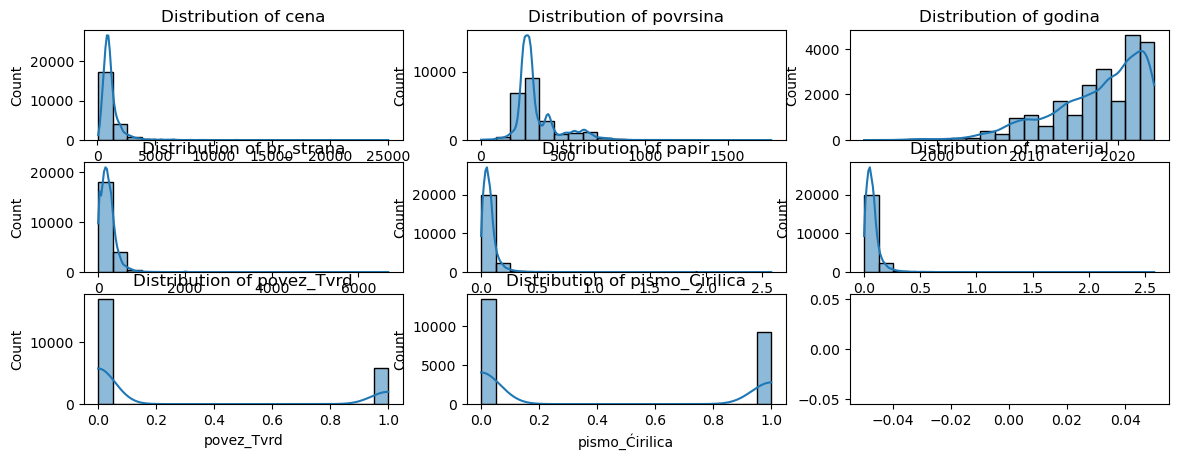

In [38]:
num = ['cena', 'povrsina', 'godina', 'br_strana', 'papir', 'materijal', 'povez_Tvrd', 'pismo_Ćirilica',
      'log_povez_Tvrd', 'log_materijal', '2_povez_Tvrd', '2_materijal', '3_povez_Tvrd', '3_materijal',
       '4_povez_Tvrd', '4_materijal', 'sqrt_povez_Tvrd', 'sqrt_materijal']
plt.figure(figsize=(14, 10))

for i, col in enumerate(num, 1):
    plt.subplot(6, 3, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

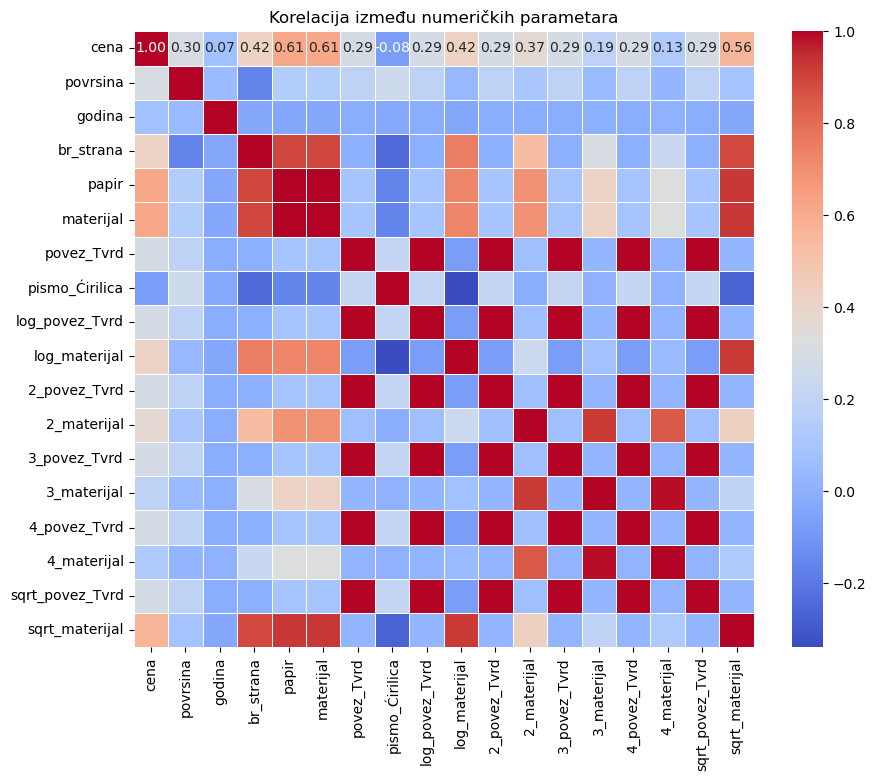

In [39]:
plt.figure(figsize=(10, 8))
num = df[['cena', 'povrsina', 'godina', 'br_strana', 'papir', 'materijal', 'povez_Tvrd', 'pismo_Ćirilica',
      'log_povez_Tvrd', 'log_materijal', '2_povez_Tvrd', '2_materijal', '3_povez_Tvrd', '3_materijal',
       '4_povez_Tvrd', '4_materijal', 'sqrt_povez_Tvrd', 'sqrt_materijal']].select_dtypes(include=['number', 'bool'])
sns.heatmap(num.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelacija između numeričkih parametara')
plt.show()

Sa obzirom na malu korelaciju godine izdanja ovu promenljivu neću dirati za izopštavanje ekstremnih vrednosti dok za cenu i broj straana sigurno hoću, a površina zavisi od broja izgubljenih podataka

In [41]:
num = ['cena', 'povrsina', 'br_strana']

for col in num:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f'Broj podataka nakon uklanjanja: {len(df)}')

Broj podataka nakon uklanjanja: 21410


C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

ValueError: num must be an integer with 1 <= num <= 8, not 9

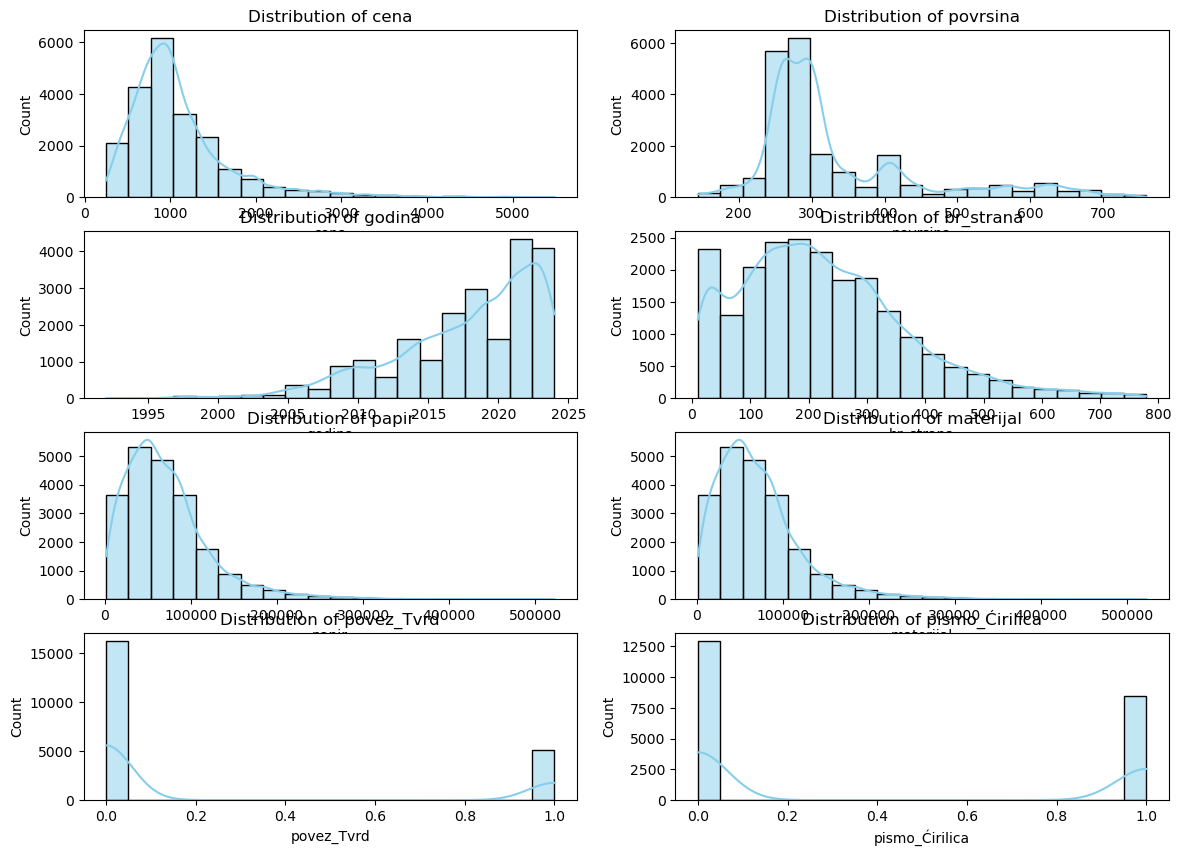

In [43]:
num = ['cena', 'povrsina', 'godina', 'br_strana', 'papir', 'materijal', 'povez_Tvrd', 'pismo_Ćirilica',
      'log_povez_Tvrd', 'log_materijal', '2_povez_Tvrd', '2_materijal', '3_povez_Tvrd', '3_materijal',
       '4_povez_Tvrd', '4_materijal', 'sqrt_povez_Tvrd', 'sqrt_materijal']

plt.figure(figsize=(14, 10))

for i, col in enumerate(num, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

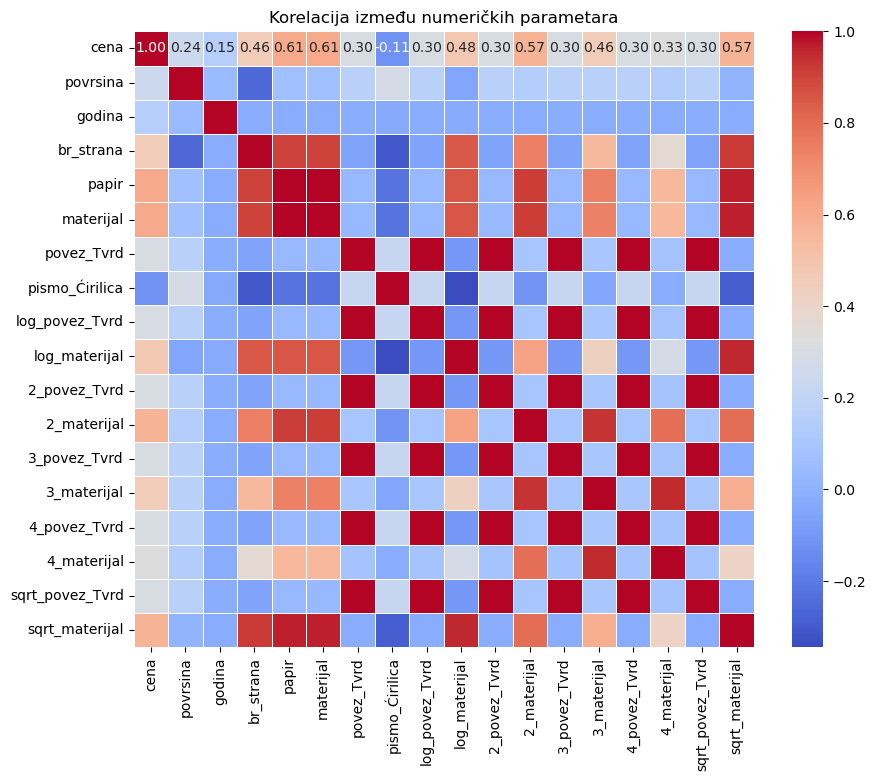

In [46]:
plt.figure(figsize=(10, 8))
num = df[['cena', 'povrsina', 'godina', 'br_strana', 'papir', 'materijal', 'povez_Tvrd', 'pismo_Ćirilica',
      'log_povez_Tvrd', 'log_materijal', '2_povez_Tvrd', '2_materijal', '3_povez_Tvrd', '3_materijal',
       '4_povez_Tvrd', '4_materijal', 'sqrt_povez_Tvrd', 'sqrt_materijal']].select_dtypes(include=['number', 'bool'])
sns.heatmap(num.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelacija između numeričkih parametara')
plt.show()

Na osnovu urađenih analiza i feature engineering-a promenljive koje najbolje utiču na predikciju cene knjiga jeste sam materijal iskorišćen za proizvodnju knjiga a to je potrošen papir (dobijen logikom množenja broja stranica sa površinom korišćenog papira) i tip koričenja. Korelacije su relativno male ali savetujući se sa resursima na internetu su dovoljne za predikciju realnog skupa podataka kao što je ovaj, direktno preuzet sa Vulkanovog sajta. Rađene su i provere korelacije u slučaju zavisnosti ovih promenljivih u funkciji korena, logaritma i drugog, treceg i četvrtog stepena, međutim nije pronađena značajna korelacija tako da će za linearnu regresiju od značaja biti promenljive o potrošenom papiru i povezu.

In [48]:
df.drop(['materijal', 'log_povez_Tvrd', 'log_materijal', '2_povez_Tvrd', '2_materijal', 
         '3_povez_Tvrd', '3_materijal', '4_povez_Tvrd', '4_materijal', 
         'sqrt_povez_Tvrd', 'sqrt_materijal'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21410 entries, 8152 to 2353
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   naslov          21410 non-null  object 
 1   autor           21410 non-null  object 
 2   zanr            21410 non-null  object 
 3   izdavac         21410 non-null  object 
 4   godina          21410 non-null  int64  
 5   br_strana       21410 non-null  int64  
 6   cena            21410 non-null  int64  
 7   povrsina        21410 non-null  float64
 8   papir           21410 non-null  float64
 9   povez_Tvrd      21410 non-null  bool   
 10  povez_drugo     21410 non-null  bool   
 11  pismo_Ćirilica  21410 non-null  bool   
dtypes: bool(3), float64(2), int64(3), object(4)
memory usage: 1.7+ MB


In [50]:
bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, float('inf')]
labels = ['0-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', 
          '2500-3000', '3000-3500', '3500-4000', '4000+']
df['kategorije_cena'] = pd.cut(df['cena'], bins=bins, labels=labels, right=False)

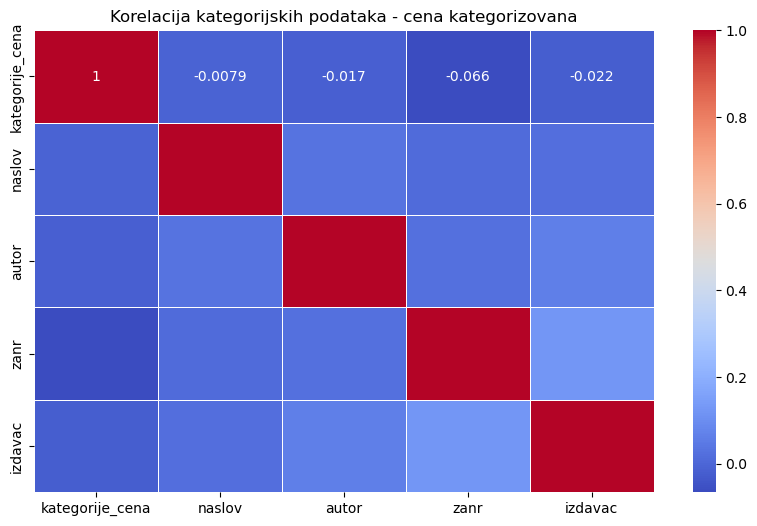

In [52]:
cat = ['kategorije_cena', 'naslov', 'autor', 'zanr', 'izdavac']
df_e = df[cat].apply(lambda x: x.astype('category').cat.codes)

plt.figure(figsize=(10, 6))
sns.heatmap(df_e.corr(), cmap='coolwarm', annot=True, linewidths=0.5)

plt.title('Korelacija kategorijskih podataka - cena kategorizovana')
plt.show()

## Modeli za predikciju
### Linearna regresija
U narednom odeljku će biti odrađena linearna regresija od početka, biti trenirana i testirana na ovom skupu podataka a zatim se odrediti njene performanse. Skup podataka nije idealan za regresiju korelacija je relativno niska, ali je to čest slučaj u realnim podacima. Kao 2 promenljive sa najvećom korelacijom `papir` i `povez_Tvrd`, biće korišćene u regresiji za predikciju promenljive `cena`.

In [54]:
#odvajanje podataka za obradu
df1 = df[['cena', 'papir', 'povez_Tvrd']]
df1= df1.sample(frac=1, random_state=42).reset_index(drop=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21410 entries, 0 to 21409
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cena        21410 non-null  int64  
 1   papir       21410 non-null  float64
 2   povez_Tvrd  21410 non-null  bool   
dtypes: bool(1), float64(1), int64(1)
memory usage: 355.6 KB


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df1.drop(columns=['cena'])
y = df1['cena']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.fit_transform(y_test.values.reshape(-1, 1)).flatten()

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

U narednim koracima biće implementirana linearna regresija sa dve promenljive. Osnovna ideja je da se minimizira greška predviđene funkcije yp = b0 + b1*x1[i] + b2*x2[i]; e = 1/n * sum(y[i] - (b0 + b1*x1[i] + b2*x2[i]))^2 => 
de/db0 = -2/n * sum(y[i] - (b0 + b1*x1[i] + b2*x2[i])); 
de/db1 = -2/n * sum(x1[i]*(y[i] - (b0 + b1*x1[i] + b2*x2[i])));
de/db2 = -2/n * sum(x2[i]*(y[i] - (b0 + b1*x1[i] + b2*x2[i])))

Kako bi vrednosti b0, b1 i b2 bile što bolje mora se ići u suprotnom smeru, tada su jednačine:
bi = bi - l * de/dbi, dge je l tendencija učenja (što je manja to daje bolje rezultate.

In [91]:
# Gradient descent funkcija
def my_gradient_decent(b0, b1, b2, X, y, L):
    yp = b0 + b1 * X.iloc[:, 0] + b2 * X.iloc[:, 1]
    
    error = y - yp
    new_b0 = b0 + 2 * L * np.mean(error)
    new_b1 = b1 + 2 * L * np.mean(X.iloc[:, 0] * error)
    new_b2 = b2 + 2 * L * np.mean(X.iloc[:, 1] * error)
    return new_b0, new_b1, new_b2


# Linearna regresija
def my_linear_regression(X, y, b0, b1, b2, L, iterations):
    for i in range(iterations):
        b0, b1, b2 = my_gradient_decent(b0, b1, b2, X, y, L)

        '''
        if (i + 1) % 100 == 0:
            #mse = np.mean((y - yp) ** 2)
            print(f"Iteration {i + 1}: b0={b0}, b1={b1}, b2={b2}, MSE={mse}")
        '''
    
    yp = b0 + b1 * X.iloc[:, 0] + b2 * X.iloc[:, 1]
    print(f"b0={b0}, b1={b1}, b2={b2}")
    return b0, b1, b2, yp

b0, b1, b2 = 0, 0, 0
L = 0.1  # Learning rate
iterations = 1000

final_b0, final_b1, final_b2, yp = my_linear_regression(X_train_scaled, y_train_scaled, b0, b1, b2, L, iterations)


b0=2.6316589677594476e-17, b1=0.6016047761454317, b2=0.2740113159117921


In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()

model.fit(X_train_scaled, y_train_scaled)

y_pred = model.predict(X_test_scaled)

C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Uros\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


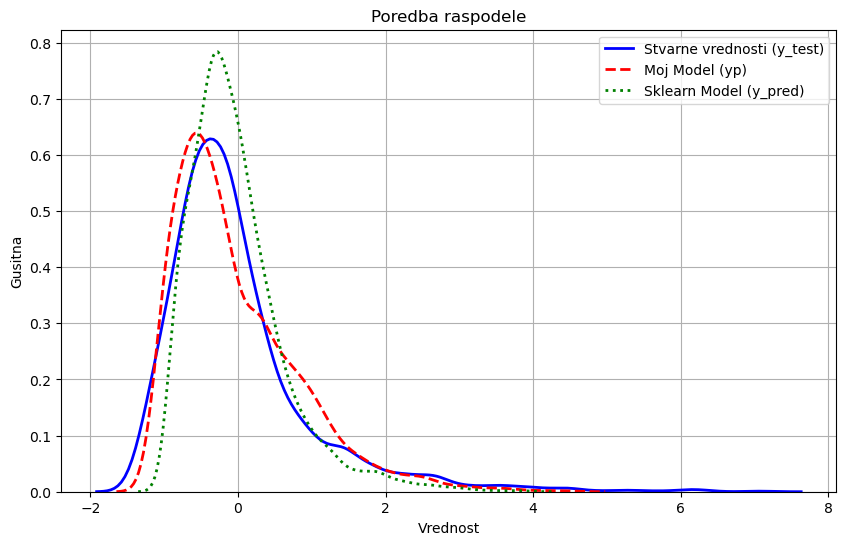

In [97]:
yp = final_b0 + final_b1 * X_test_scaled.iloc[:, 0] + final_b1 * X_test_scaled.iloc[:, 1]

y_test_scaled = np.array(y_test_scaled)
yp = np.array(yp)
y_pred = np.array(y_pred)

plt.figure(figsize=(10, 6))
sns.kdeplot(y_test_scaled, label="Stvarne vrednosti (y_test)", color="blue", linewidth=2)
sns.kdeplot(yp, label="Moj Model (yp)", color="red", linestyle="dashed", linewidth=2)
sns.kdeplot(y_pred, label="Sklearn Model (y_pred)", color="green", linestyle="dotted", linewidth=2)

plt.xlabel("Vrednost")
plt.ylabel("Gusitna")
plt.title("Poredba raspodele")
plt.legend()
plt.grid(True)

plt.show()

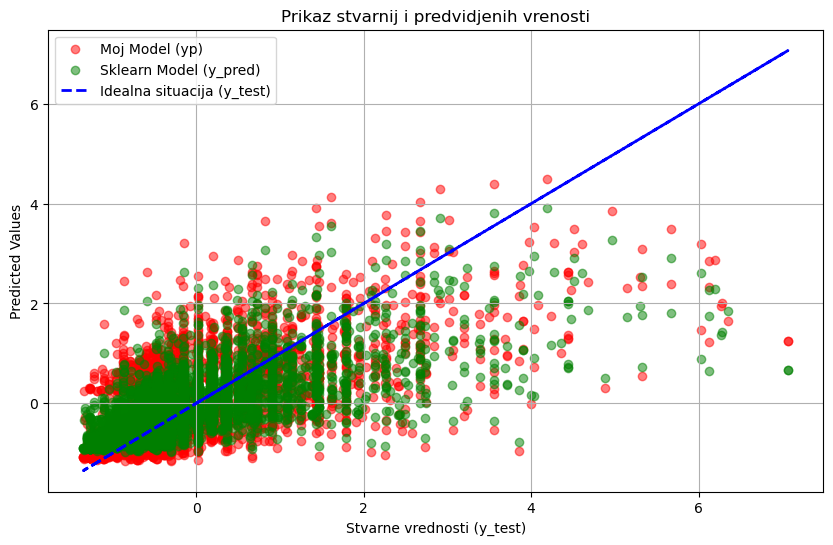

In [99]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_scaled, yp, color="red", alpha=0.5, label="Moj Model (yp)")
plt.scatter(y_test_scaled, y_pred, color="green", alpha=0.5, label="Sklearn Model (y_pred)")
plt.plot(y_test_scaled, y_test_scaled, color="blue", linestyle="dashed", linewidth=2, label="Idealna situacija (y_test)")
plt.xlabel("Stvarne vrednosti (y_test)")
plt.ylabel("Predicted Values")
plt.title("Prikaz stvarnij i predvidjenih vrenosti")
plt.legend()
plt.grid(True)
plt.show()


In [105]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_moj = mean_absolute_error(y_test_scaled, yp)
mae_sklearn = mean_absolute_error(y_test_scaled, y_pred)
r2_moj = r2_score(y_test_scaled, yp)
r2_sklearn = r2_score(y_test_scaled, y_pred)

print(f"Moj Model - MAE: {mae_moj:.4f}, R^2: {r2_moj:.4f}")
print(f"Sklearn Model - MAE: {mae_sklearn:.4f}, R^2: {r2_sklearn:.4f}")

Moj Model - MAE: 0.5514, R^2: 0.3356
Sklearn Model - MAE: 0.4909, R^2: 0.4352


Oba modela daju korektne rezultate uzimajući metrike u obzi